In [2]:
import os
import glob
import shutil
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import ttest_ind
from natsort import natsorted
from sklearn.decomposition import PCA
import nibabel.freesurfer.io as fsio
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
import glob
from statsmodels.stats.multitest import multipletests
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os
from scipy.stats import linregress
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind
from sklearn.metrics import pairwise_distances
import nibabel as nib
import sys
import seaborn as sns
from nibabel import cifti2
from scipy.spatial import procrustes
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind, ttest_rel
from statsmodels.stats.multitest import multipletests
np.random.seed(42)

In [3]:
blind_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_nativespace_split_fingerprint_fc_rh_Schaefer2nativespace_splitTHOMAS.npy')
control_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_nativespace_split_fingerprint_fc_rh_Schaefer2nativespace_splitTHOMAS.npy')
#blind_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_nativespace_fingerprint_fc_rh_Schaefer2nativespaceTHOMAS.npy')
#control_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_nativespace_fingerprint_fc_rh_Schaefer2nativespaceTHOMAS.npy')

In [4]:
region_label = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 8,
       8, 8, 2, 8, 8, 8, 8, 8, 8, 8, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8,
       2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 8, 8, 8, 2, 8, 8, 2, 8, 8, 8, 8, 8, 2, 2, 2, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 2,
       2, 8, 2, 8]

network_names = ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default', 'Auditory']
labels = [f"{i}_{j}" for i in network_names for j in network_names]

In [5]:
labels, ctab, names = nib.freesurfer.read_annot('../Dataset/template/rh.HCPMMP1.annot')
roi_names = [name.decode('utf-8') for name in names]
MMPname = roi_names[1:]

# Blind

In [7]:
nucleis = np.load('../Dataset/blind/thalamus_right_labels_Italy.npy')
nucleilabel = ['AV', 'VA', 'VLa', 'VLp', 'VPL', 'Pul', 'LGN', 'MGN', 'CM', 'MD-Pf', 'Hb',  'MTT', 'Acc', 'Cau', 'Cla', 'GPe', 'GPi', 'Put', 'RN' ,'Pul_d', 'Pul_v']

In [8]:
cb = pd.read_csv('../Dataset/fingerprint_FC_dataset/Italy_blind_subjects', header=None)[0].values
sc = pd.read_csv('../Dataset/fingerprint_FC_dataset/Italy_control_subjects', header=None)[0].values

In [9]:
blind_V1 = []
blind_A1 = []
for i in np.arange(blind_MMP_rh.shape[0]):
    corr_matrix = blind_MMP_rh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)#.T / pd.DataFrame(corr_matrix).mean(axis=1)
    #corr_df = corr_df.T
    corr_df.index = nucleilabel
    corr_df.columns = region_label[200:]
    V1_cols = [idx for idx, label in enumerate(region_label[200:]) if 1==label]
    A1_cols = [idx for idx, label in enumerate(region_label[200:]) if 6==label]
    visual_df = corr_df.iloc[:, V1_cols]
    auditory_df = corr_df.iloc[:, A1_cols]
    avg_visual = visual_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    avg_auditory = auditory_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    blind_V1.append(avg_visual)
    blind_A1.append(avg_auditory)

In [10]:
control_V1 = []
control_A1 = []
for i in np.arange(control_MMP_rh.shape[0]):
    corr_matrix = control_MMP_rh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)#.T / pd.DataFrame(corr_matrix).mean(axis=1)
    #corr_df = corr_df.T
    corr_df.index = nucleilabel
    corr_df.columns = region_label[200:]
    visual_df = corr_df.iloc[:, V1_cols]
    auditory_df = corr_df.iloc[:, A1_cols]
    avg_visual = visual_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    avg_auditory = auditory_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    control_V1.append(avg_visual)
    control_A1.append(avg_auditory)

In [11]:
df_A1 = pd.concat([pd.DataFrame(blind_A1), pd.DataFrame(control_A1)]).reset_index(drop=True)
df_A1.columns = nucleilabel
df_A1['group'] = list(np.repeat('blind', len(blind_A1))) +  list(np.repeat('control', len(control_A1)))

In [12]:
df_V1 = pd.concat([pd.DataFrame(blind_V1), pd.DataFrame(control_V1)]).reset_index(drop=True)
df_V1.columns = nucleilabel
df_V1['group'] = list(np.repeat('blind', len(blind_A1))) +  list(np.repeat('control', len(control_A1)))

In [13]:
df_V1_network = df_V1

In [14]:
features = df_A1.iloc[:, :-1]
group = df_A1['group']
df_A1_network = features.T.groupby(features.columns).mean().T
#df_A1_network = df_A1_network.div(features.mean(axis=1), axis=0)
df_A1_network.columns = nucleilabel
#df_A1_network['subject'] = list(cb) + list(sc)
df_A1_network['group'] = group

/tmp/ipykernel_1613390/3268045868.py:115: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(network_order, rotation=30)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


AV 2.6102207768277106 0.013812386620286925
VA 3.8630353678464324 0.0005137850448932714
VLa 1.9963123455118137 0.054467702374549155
VLp 2.7782671207009773 0.009067060667381248
VPL -0.8639985549804572 0.39401901455397315
Pul nan nan
LGN 2.00079949000886 0.05423651014759948
MGN -1.0710466090098245 0.29241667733322535
CM -1.2393237988415704 0.22483384616240393
MD-Pf 2.4446624008887903 0.020187676012962626
Pul_d -0.049309929463994276 0.9609788011845357
Pul_v -0.9075232297780377 0.37091405950378153
FDR-corrected p-values: [0.05064542 0.00565164 0.09985745 0.04986883 0.43342092 0.09985745
 0.40207293 0.35331033 0.05551611 0.9609788  0.43342092]


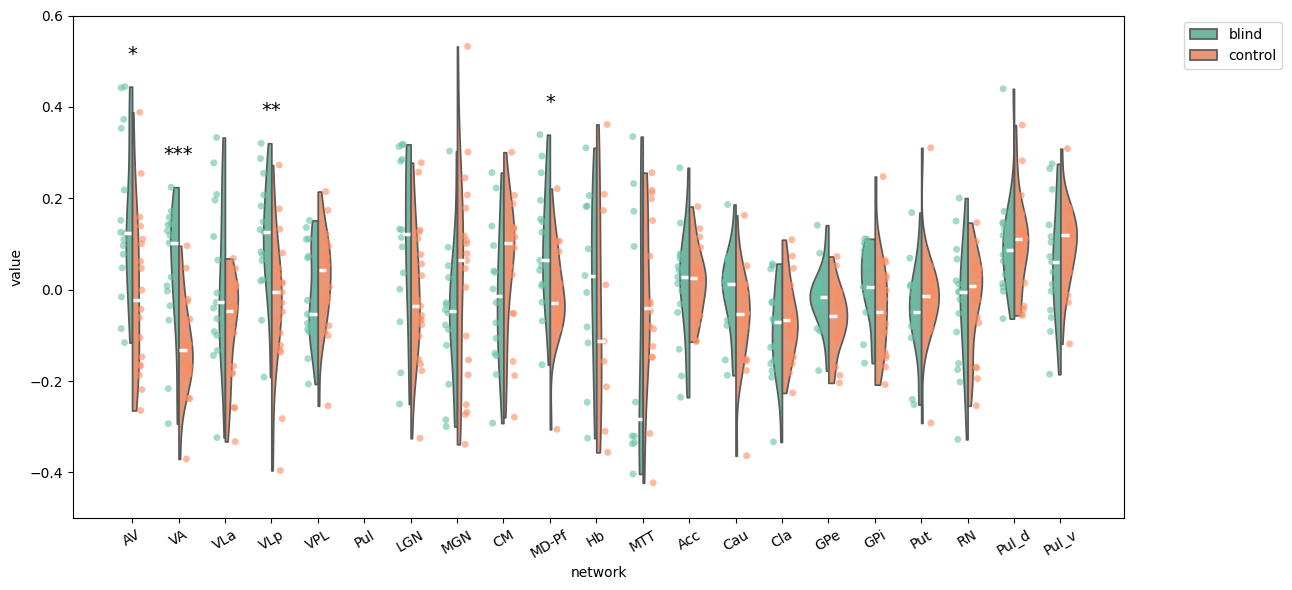

In [15]:
for region in [df_V1_network]:

    # -------------------------
    # Long format
    # -------------------------
    df_long = region.melt(
        id_vars=['group'],
        var_name='network',
        value_name='value'
    )

    network_order = df_long['network'].unique()

    plt.figure(figsize=(13, 6))

    ax = sns.violinplot(
        x='network',
        y='value',
        hue='group',
        data=df_long,
        order=network_order,
        split=True,
        inner=None,
        cut=0,
        palette="Set2"
    )

    sns.stripplot(
        x='network',
        y='value',
        hue='group',
        data=df_long,
        order=network_order,
        dodge=True,
        jitter=True,
        marker='o',
        alpha=0.6,
        palette="Set2",
        ax=ax
    )

    # -------------------------
    # Median lines
    # -------------------------
    medians = (
        df_long.groupby(['network', 'group'])['value']
        .median()
        .reset_index()
    )

    offset = 0.18

    for i, net in enumerate(network_order):
        for group, sign in zip(['blind', 'control'], [-1, 1]):

            val = medians.loc[
                (medians['network'] == net) &
                (medians['group'] == group),
                'value'
            ].values

            if len(val) == 0:
                continue

            ax.hlines(
                y=val[0],
                xmin=i + sign * 0.02,
                xmax=i + sign * offset,
                color='white',
                linewidth=2.5,
                zorder=10
            )

    # -------------------------
    # Statistics + stars
    # -------------------------
    pvals = []
    for i, net in enumerate(list(network_order[:10])+list(network_order[-2:])):

        blind = df_long[(df_long['group'] == 'blind') & (df_long['network'] == net)]['value']
        control = df_long[(df_long['group'] == 'control') & (df_long['network'] == net)]['value']

        t, p = ttest_ind(blind, control, nan_policy='omit')
        pvals.append(p)
        print(net, t, p)

        if p < 0.001:
            star = '***'
        elif p < 0.01:
            star = '**'
        elif p < 0.05:
            star = '*'
        else:
            star = ''

        y_max = df_long[df_long['network'] == net]['value'].max()

        ax.text(
            i,
            y_max + 0.05,
            star,
            ha='center',
            va='bottom',
            fontsize=14
        )

    pvals_clean = [p for p in pvals if not pd.isna(p)]
    _, p_fdr, _, _ = multipletests(pvals_clean, method='fdr_bh')
    print('FDR-corrected p-values:', p_fdr)

    # -------------------------
    # Formatting
    # -------------------------
    ax.set_ylim([-0.5, 0.6])
    ax.set_xticklabels(network_order, rotation=30)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig('sommot_thalamus_blind_nuclei_violin.eps')
    plt.show()

# Deaf

In [16]:
nucleis = np.load('../Dataset/deaf/thalamus_right_labels_Deaf.npy')
nucleilabel = ['AV', 'VA', 'VLa', 'VLp', 'VPL', 'Pul', 'LGN', 'MGN', 'CM', 'MD-Pf', 'Hb',  'MTT', 'Acc', 'Cau', 'Cla', 'GPe', 'GPi', 'Put', 'RN'] #, 'Pul_d', 'Pul_v']

In [17]:
deaf = pd.read_csv('../Dataset/fingerprint_FC_dataset/Deaf_deaf_subjects', header=None)[0].values
deaf_control = pd.read_csv('../Dataset/fingerprint_FC_dataset/Deaf_deaf_control_subjects', header=None)[0].values

In [18]:
deaf_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/deafsource_deaftarget_nativespace_fingerprint_fc_rh_Schaefer2nativespaceTHOMAS.npy') #_split
deaf_control_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/deaf_controlsource_deaf_controltarget_nativespace_fingerprint_fc_rh_Schaefer2nativespaceTHOMAS.npy')

In [19]:
deaf_V1 = []
deaf_A1 = []
for i in np.arange(deaf_MMP_rh.shape[0]):
    corr_matrix = deaf_MMP_rh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)
    corr_df.index = nucleilabel
    corr_df.columns = region_label[200:]
    V1_cols = [idx for idx, label in enumerate(region_label[200:]) if 6==label]
    A1_cols = [idx for idx, label in enumerate(region_label[200:]) if 6==label]
    visual_df = corr_df.iloc[:, V1_cols]
    auditory_df = corr_df.iloc[:, A1_cols]
    avg_visual = visual_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    avg_auditory = auditory_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    deaf_V1.append(avg_visual)
    deaf_A1.append(avg_auditory)

In [20]:
control_V1 = []
control_A1 = []
for i in np.arange(deaf_control_MMP_rh.shape[0]):
    corr_matrix = deaf_control_MMP_rh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)
    corr_df.index = nucleilabel
    corr_df.columns = region_label[200:]
    visual_df = corr_df.iloc[:, V1_cols]
    auditory_df = corr_df.iloc[:, A1_cols]
    avg_visual = visual_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    avg_auditory = auditory_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    control_V1.append(avg_visual)
    control_A1.append(avg_auditory)

In [21]:
df_A1 = pd.concat([pd.DataFrame(deaf_A1), pd.DataFrame(control_A1)]).reset_index(drop=True)
df_A1.columns = nucleilabel
#df_A1['subject'] = list(cb) + list(sc)
df_A1['group'] = list(np.repeat('deaf', len(deaf_V1))) +  list(np.repeat('control', len(control_V1)))

In [22]:
df_V1 = pd.concat([pd.DataFrame(deaf_V1), pd.DataFrame(control_V1)]).reset_index(drop=True)
df_V1.columns = nucleilabel
df_V1['group'] = list(np.repeat('deaf', len(deaf_V1))) +  list(np.repeat('control', len(control_V1)))

In [23]:
features = df_V1.iloc[:, :-1]
group = df_V1['group']
df_V1_network = features.T.groupby(features.columns).mean().T
#df_V1_network = df_V1_network.div(features.mean(axis=1), axis=0)
df_V1_network.columns = nucleilabel 
#df_V1_network['subject'] = list(deaf) + list(deaf_control)
df_V1_network['group'] = group

In [24]:
#features = df_A1.iloc[:, :-1]
#group = df_A1['group']
#df_A1_network = features.T.groupby(features.columns).mean().T
#df_A1_network = df_A1_network.div(features.mean(axis=1), axis=0)
#df_A1_network.columns = nucleilabel
#df_A1_network['subject'] = list(deaf) + list(deaf_control)
#df_A1_network['group'] = group
#df_A1_network = df_A1_network[df_A1_network.MGN>-50]
#df_A1_network = df_A1_network[df_A1_network.MGN<50]
df_A1_network = df_A1.copy()

/tmp/ipykernel_1613390/3752201191.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(network_order, rotation=30)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


AV 0.14643860935643505 0.8841307385287606
VA -1.3223836839137673 0.19171881663308896
VLa -0.18854897960851136 0.8511664435779471
VLp -0.9309944282525414 0.3560779433156849
VPL 0.11018041592532389 0.9126824484876054
Pul -2.3016199195497244 0.025316631656622526
LGN -1.0901675830487656 0.28057110598295937
MGN 0.5115988221166305 0.6111399066415597
CM -0.9534869036862782 0.3446720160493437
MD-Pf -0.671177809994945 0.5050220606478821
FDR-corrected p-values: [0.91268245 0.71215589 0.91268245 0.71215589 0.91268245 0.25316632
 0.71215589 0.87305701 0.71215589 0.84170343]


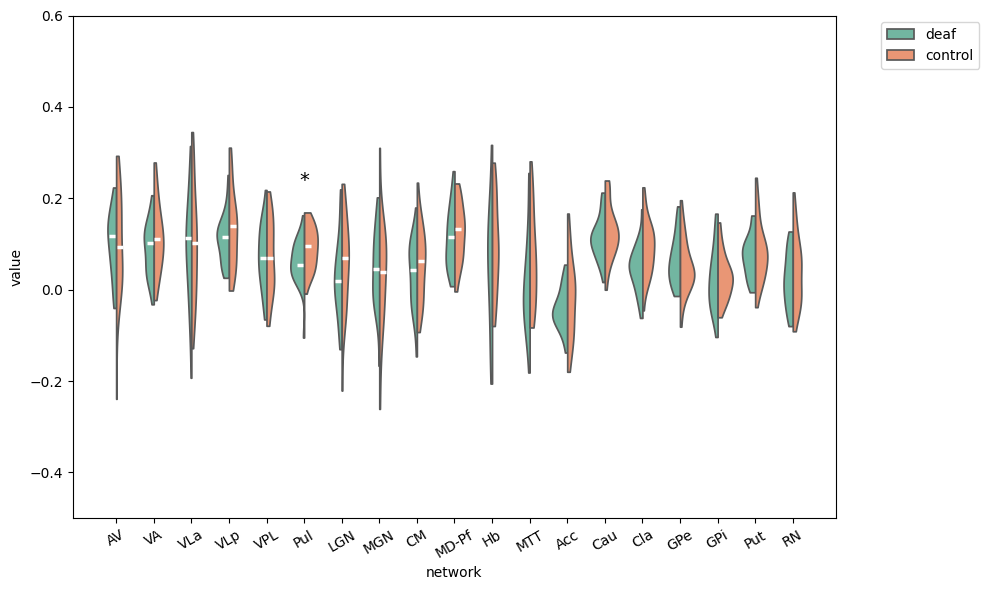

In [25]:
for region in [df_A1_network]:

    # -------------------------
    # Long format
    # -------------------------
    df_long = region.melt(
        id_vars=['group'],
        var_name='network',
        value_name='value'
    )

    network_order = df_long['network'].unique()

    plt.figure(figsize=(10, 6))

    ax = sns.violinplot(
        x='network',
        y='value',
        hue='group',
        data=df_long,
        order=network_order,
        split=True,
        inner=None,
        cut=0,
        palette="Set2"
    )

    # -------------------------
    # Median lines
    # -------------------------
    medians = (
        df_long.groupby(['network', 'group'])['value']
        .median()
        .reset_index()
    )

    offset = 0.18

    # -------------------------
    # Stats
    # -------------------------
    pvals = []

    for i, net in enumerate(network_order[:10]):

        deaf = df_long[(df_long['group'] == 'deaf') & (df_long['network'] == net)]['value']
        control = df_long[(df_long['group'] == 'control') & (df_long['network'] == net)]['value']

        t, p = ttest_ind(deaf, control, nan_policy='omit')
        print(net, t, p)
        

        pvals.append(p)

        # stars (uncorrected)
        if p < 0.001:
            star = '***'
        elif p < 0.01:
            star = '**'
        elif p < 0.05:
            star = '*'
        else:
            star = ''

        y_max = df_long[df_long['network'] == net]['value'].max()

        ax.text(
            i,
            y_max + 0.05,
            star,
            ha='center',
            va='bottom',
            fontsize=14
        )

        # median lines (per group)
        for group, sign in zip(['deaf', 'control'], [-1, 1]):

            val = medians.loc[
                (medians['network'] == net) &
                (medians['group'] == group),
                'value'
            ].values

            if len(val) == 0:
                continue

            ax.hlines(
                y=val[0],
                xmin=i + sign * 0.02,
                xmax=i + sign * offset,
                color='white',
                linewidth=2.5,
                zorder=10
            )

    # -------------------------
    # FDR correction (fixed)
    # -------------------------
    pvals_clean = [p for p in pvals if not pd.isna(p)]
    _, p_fdr, _, _ = multipletests(pvals_clean, method='fdr_bh')
    print("FDR-corrected p-values:", p_fdr)

    # -------------------------
    # Formatting
    # -------------------------
    ax.set_xticklabels(network_order, rotation=30)
    ax.set_ylim([-0.5, 0.6])

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig('deaf_thalamus_violin.eps')
    plt.show()